<a href="https://colab.research.google.com/github/RithigaChandrasekar-0512/HousePrice_Prediction/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving house_prices_practice.csv to house_prices_practice.csv


In [ ]:
import pandas as pd

df = pd.read_csv("house_prices_practice.csv")
print(df.columns)

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')


In [ ]:
print(df.columns)

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB
None
               Id  OverallQual    GrLivArea  GarageCars  TotalBsmtSF  \
count  300.000000   300.000000   300.000000  300.000000   300.000000   
mean   150.500000     5.326667  2307.386667    1.330000  1468.796667   
std     86.746758     2.873001  1042.561303    1.109898   672.333705   
min      1.000000     1.000000   504.000000    0.000000   303.000000  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features
X = df.drop(['Id', 'SalePrice'], axis=1)

# Target
y = df['SalePrice']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 21414.515000000007
R2 Score: 0.8676243539162354


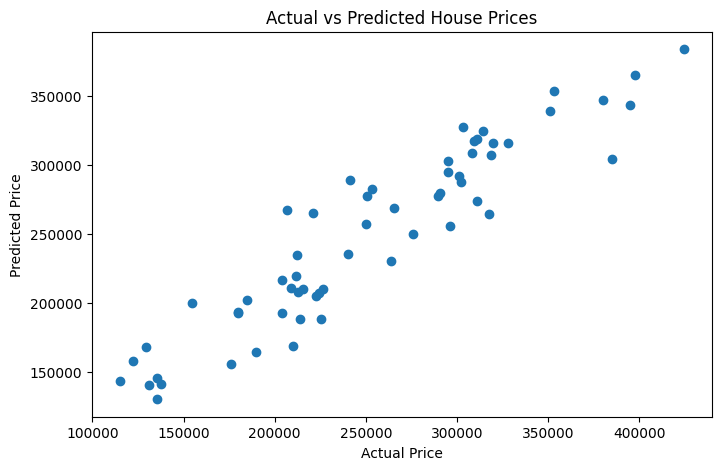

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [ ]:
new_house = [[
    8,      # OverallQual
    2000,   # GrLivArea
    2,      # GarageCars
    1200,   # TotalBsmtSF
    2010,   # YearBuilt
    2,      # FullBath
    3,      # BedroomAbvGr
    9000    # LotArea
]]

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 270242.49


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
